In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
clean_data_df=pd.read_csv("../cleaned_data/cleaned_data_2_20_26.csv")

In [3]:
clean_data_df.head()

,Unnamed: 0,team_name,opponent_name,opponent_pts,team_box_id,game_id,team_id,is_home,win,pts,...,diff_fg3m_average,diff_fg3a_average,diff_days_rest_average,diff_win_percentage_average,diff_wins_last_5_average,diff_wins_last_10_average,diff_win_percentage_last_5_average,diff_win_percentage_last_10_average,diff_pace_rolling_mean_prev_5,diff_pace_average
0,0,76ers,Wizards,107,2140,22000013,1610612755,True,True,113,...,-5.000000,1.000000,0.00,1.000000,-2.000000,-4.00,0.000000,0.000000,-98.0,0.000
1,1,76ers,Knicks,89,2103,22000025,1610612755,False,True,109,...,-1.000000,1.500000,0.00,1.000000,-0.500000,-1.50,0.500000,0.500000,1.0,0.750
2,2,76ers,Cavaliers,118,2100,22000035,1610612755,False,False,94,...,0.333333,5.666667,0.00,0.555556,-0.333333,-1.00,0.333333,0.333333,-1.0,-1.010
3,3,76ers,Raptors,93,2061,22000049,1610612755,True,True,100,...,-2.000000,0.750000,-0.25,0.604167,0.250000,-0.25,0.416667,0.416667,-4.0,-2.625
4,4,76ers,Magic,92,2028,22000064,1610612755,False,True,116,...,0.000000,1.600000,-0.20,0.483333,0.000000,-0.40,0.283333,0.283333,-4.0,-2.600


In [4]:
unneeded_columns=['team_name','opponent_name','opponent_pts',
 'team_box_id', 'game_id', 'team_id',
 'season_year', 'game_date', 'neutral_site',
 'opponent_team_id', 'game_number', 'pts',
 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct',
 'ftm', 'fta', 'ft_pct',
 'oreb', 'dreb', 'reb',
 'ast', 'tov', 'stl', 'blk', 'blka',
 'pf', 'pfd',
 'pace', 'poss', 'minutes_played',
 'total_wins', 'total_losses', 'diff_pts',
 'diff_ast', 'diff_tov', 'total_wins', 'total_losses',
 'diff_pts', 'diff_ast', 'diff_tov',
 'diff_blk', 'diff_blka', 'diff_fgm',
 'diff_fga', 'diff_ftm', 'diff_fta',
 'diff_pf', 'diff_pfd', 'diff_stl',
 'diff_oreb', 'diff_dreb', 'diff_fg3m',
 'diff_fg3a', 'diff_days_rest_average',
 'diff_days_rest_rolling_mean_prev_5',
 'diff_win_percentage_average',
 'diff_win_percentage_last_10_average',
 'diff_win_percentage_last_10_rolling_mean_prev_5',
 'diff_win_percentage_last_5_average',
 'diff_win_percentage_last_5_rolling_mean_prev_5',
 'diff_win_percentage_rolling_mean_prev_5',
 'diff_wins_last_10_average',
 'diff_wins_last_10_rolling_mean_prev_5',
 'diff_wins_last_5_average',
 'diff_wins_last_5_rolling_mean_prev_5',
 'diff_days_rest_rolling_mean_prev_10',
 'diff_win_percentage_last_10_rolling_mean_prev_10',
 'diff_wins_last_10_rolling_mean_prev_10',
 'diff_wins_last_5_rolling_mean_prev_10', 
 'Unnamed: 0'                ]

In [5]:
cols = [col for col in clean_data_df.columns if col not in unneeded_columns]
df = clean_data_df[cols]

In [6]:
in_game_factors = ['win', 'pts', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'tov', 
 'stl', 'blk', 'blka', 'pf', 'pfd', 'pace', 'poss','days_rest', 'wins_last_10', 'wins_last_5', 'win_percentage', 'win_percentage_last_10',
    'win_percentage_last_5', 'is_home', 'is_back_to_back',
    'diff_win_percentage', 'diff_win_percentage_last_10', 'diff_win_percentage_last_5',
    'diff_wins_last_10', 'diff_wins_last_5', 'diff_days_rest',
    'ast_average', 'blk_average', 'blka_average', 'dreb_average', 'fg3a_average',
    'fg3m_average', 'fga_average', 'fgm_average', 'fta_average', 'ftm_average',
    'oreb_average', 'pace_average', 'pf_average', 'pfd_average', 'pts_average',
    'reb_average', 'stl_average', 'tov_average',
    'diff_ast_average', 'diff_blk_average', 'diff_blka_average', 'diff_dreb_average',
    'diff_fg3a_average', 'diff_fg3m_average', 'diff_fga_average', 'diff_fgm_average',
    'diff_fta_average', 'diff_ftm_average', 'diff_oreb_average', 'diff_pace_average',
    'diff_pf_average', 'diff_pfd_average', 'diff_pts_average', 'diff_stl_average',
    'diff_tov_average',
    'ast_rolling_mean_prev_5', 'blk_rolling_mean_prev_5', 'blka_rolling_mean_prev_5',
    'dreb_rolling_mean_prev_5', 'fg3a_rolling_mean_prev_5', 'fg3m_rolling_mean_prev_5',
    'fga_rolling_mean_prev_5', 'fgm_rolling_mean_prev_5', 'fta_rolling_mean_prev_5',
    'ftm_rolling_mean_prev_5', 'oreb_rolling_mean_prev_5', 'pace_rolling_mean_prev_5',
    'pf_rolling_mean_prev_5', 'pfd_rolling_mean_prev_5', 'pts_rolling_mean_prev_5',
    'reb_rolling_mean_prev_5', 'stl_rolling_mean_prev_5', 'tov_rolling_mean_prev_5',
    'diff_ast_rolling_mean_prev_5', 'diff_blk_rolling_mean_prev_5', 'diff_blka_rolling_mean_prev_5',
    'diff_dreb_rolling_mean_prev_5', 'diff_fg3a_rolling_mean_prev_5', 'diff_fg3m_rolling_mean_prev_5',
    'diff_fga_rolling_mean_prev_5', 'diff_fgm_rolling_mean_prev_5', 'diff_fta_rolling_mean_prev_5',
    'diff_ftm_rolling_mean_prev_5', 'diff_oreb_rolling_mean_prev_5', 'diff_pace_rolling_mean_prev_5',
    'diff_pf_rolling_mean_prev_5', 'diff_pfd_rolling_mean_prev_5', 'diff_pts_rolling_mean_prev_5',
    'diff_stl_rolling_mean_prev_5', 'diff_tov_rolling_mean_prev_5'
]

in_game_df = clean_data_df[in_game_factors]


In [7]:
df.head()

,is_home,win,days_rest,is_back_to_back,win_percentage,wins_last_5,wins_last_10,win_percentage_last_5,win_percentage_last_10,diff_days_rest,...,diff_fta_average,diff_pf_average,diff_pfd_average,diff_stl_average,diff_oreb_average,diff_dreb_average,diff_fg3m_average,diff_fg3a_average,diff_pace_rolling_mean_prev_5,diff_pace_average
0,True,True,0.0,0,1.000000,0,0,0.000000,0.000000,0.0,...,7.00,-1.000000,1.000000,4.00,5.000000,2.000000,-5.000000,1.000000,-98.0,0.000
1,False,True,3.0,0,1.000000,1,1,1.000000,1.000000,0.0,...,3.00,-2.500000,2.500000,3.50,2.000000,3.500000,-1.000000,1.500000,1.0,0.750
2,False,False,1.0,1,0.666667,2,2,1.000000,1.000000,0.0,...,4.00,-2.666667,2.666667,1.00,0.333333,1.333333,0.333333,5.666667,-1.0,-1.010
3,True,True,2.0,0,0.750000,2,2,0.666667,0.666667,-1.0,...,7.75,-5.250000,5.250000,0.25,0.000000,3.000000,-2.000000,0.750000,-4.0,-2.625
4,False,True,2.0,0,0.800000,3,3,0.750000,0.750000,0.0,...,5.00,-2.600000,2.600000,1.20,-0.600000,4.200000,0.000000,1.600000,-4.0,-2.600


In [8]:
in_game_df.head()

,win,pts,fgm,fga,fg_pct,fg3m,fg3a,fg3_pct,ftm,fta,...,diff_fgm_rolling_mean_prev_5,diff_fta_rolling_mean_prev_5,diff_ftm_rolling_mean_prev_5,diff_oreb_rolling_mean_prev_5,diff_pace_rolling_mean_prev_5,diff_pf_rolling_mean_prev_5,diff_pfd_rolling_mean_prev_5,diff_pts_rolling_mean_prev_5,diff_stl_rolling_mean_prev_5,diff_tov_rolling_mean_prev_5
0,True,113,41,87,0.471,8,28,0.286,23,30,...,0,0,0,0,-98.0,0,0,0,0,0
1,True,109,41,88,0.466,11,31,0.355,16,22,...,2,7,7,5,1.0,-1,1,6,4,-2
2,False,94,33,79,0.418,12,37,0.324,16,22,...,5,3,3,2,-1.0,-2,2,13,3,-3
3,True,100,32,84,0.381,8,31,0.258,28,33,...,-1,4,3,0,-4.0,-2,2,0,1,0
4,True,116,44,91,0.484,15,33,0.455,13,15,...,-1,7,6,0,-4.0,-5,5,2,0,0


In [9]:
### EDA

In [10]:
# HOME vs AWAY Performance
print("="*80)
print("HOME VS AWAY ANALYSIS")
print("="*80)

home_win_pct = in_game_df[in_game_df['is_home'] == 1]['win'].mean()
away_win_pct = in_game_df[in_game_df['is_home'] == 0]['win'].mean()

print(f"Home win %: {home_win_pct:.2%}")
print(f"Away win %: {away_win_pct:.2%}")
print(f"Home advantage: +{(home_win_pct - away_win_pct)*100:.1f}%")

HOME VS AWAY ANALYSIS
Home win %: 55.10%
Away win %: 44.92%
Home advantage: +10.2%


In [11]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Convert win to binary if needed
if in_game_df['win'].dtype == bool:
    in_game_df['win'] = in_game_df['win'].astype(int)

In [12]:
##  Statistical Summary by Win/Loss 
print("\n" + "="*80)
print("STATISTICAL SUMMARY BY WIN/LOSS")
print("="*80)

# Split data by win/loss
wins = in_game_df[in_game_df['win'] == 1]
losses = in_game_df[in_game_df['win'] == 0]

# Select numeric columns for comparison
numeric_cols = in_game_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('win')

# Create comparison dataframe
comparison_stats = pd.DataFrame({
    'Wins_Mean': wins[numeric_cols].mean(),
    'Wins_Std': wins[numeric_cols].std(),
    'Losses_Mean': losses[numeric_cols].mean(),
    'Losses_Std': losses[numeric_cols].std(),
    'Difference': wins[numeric_cols].mean() - losses[numeric_cols].mean(),
    'Diff_Percent': ((wins[numeric_cols].mean() - losses[numeric_cols].mean()) / losses[numeric_cols].mean().abs()) * 100
})

# Add t-test p-values
p_values = []
for col in numeric_cols:
    if wins[col].notna().sum() > 0 and losses[col].notna().sum() > 0:
        t_stat, p_val = stats.ttest_ind(wins[col].dropna(), losses[col].dropna())
        p_values.append(p_val)
    else:
        p_values.append(np.nan)

comparison_stats['P_Value'] = p_values
comparison_stats['Significant'] = comparison_stats['P_Value'] < 0.05

# Sort by absolute difference
comparison_stats = comparison_stats.sort_values('Difference', key=abs, ascending=False)

print("\nTop features that differentiate wins from losses:")
print(comparison_stats.head(20).round(4))


STATISTICAL SUMMARY BY WIN/LOSS

Top features that differentiate wins from losses:
                              Wins_Mean  Wins_Std  Losses_Mean  Losses_Std  \
pts                            119.5157   11.0079     107.2823     11.1232   
fgm                             43.7355    4.8587      39.4219      4.7070   
dreb                            35.3569    5.1629      31.3876      4.8766   
reb                             45.8948    6.4463      42.0231      6.2390   
diff_pts_average                 1.9268    5.3603      -1.9151      5.6427   
ast                             27.3380    5.1256      24.1199      4.6397   
diff_pts_rolling_mean_prev_5     1.3567    7.8309      -1.3507      8.1690   
fg3m                            13.8992    4.0000      11.7649      3.5331   
pts_average                    113.8783    5.0223     112.0489      5.0642   
ftm                             18.1455    6.0741      16.6736      5.5519   
diff_wins_last_10                0.7021    2.7685      -0.


CORRELATION WITH WIN

Features most positively correlated with winning:
pts                    0.4838
diff_win_percentage    0.4629
fg_pct                 0.4561
fgm                    0.4111
dreb                   0.3676
win_percentage         0.3640
fg3_pct                0.3569
diff_pts_average       0.3296
ast                    0.3127
reb                    0.2919
Name: win, dtype: float64

Features most negatively correlated with winning:
pf                              -0.0677
diff_pace_average               -0.0694
diff_blka_rolling_mean_prev_5   -0.0789
blka_rolling_mean_prev_5        -0.0872
tov                             -0.0930
tov_average                     -0.1046
diff_tov_average                -0.1058
diff_blka_average               -0.1356
blka_average                    -0.1390
blka                            -0.1538
Name: win, dtype: float64


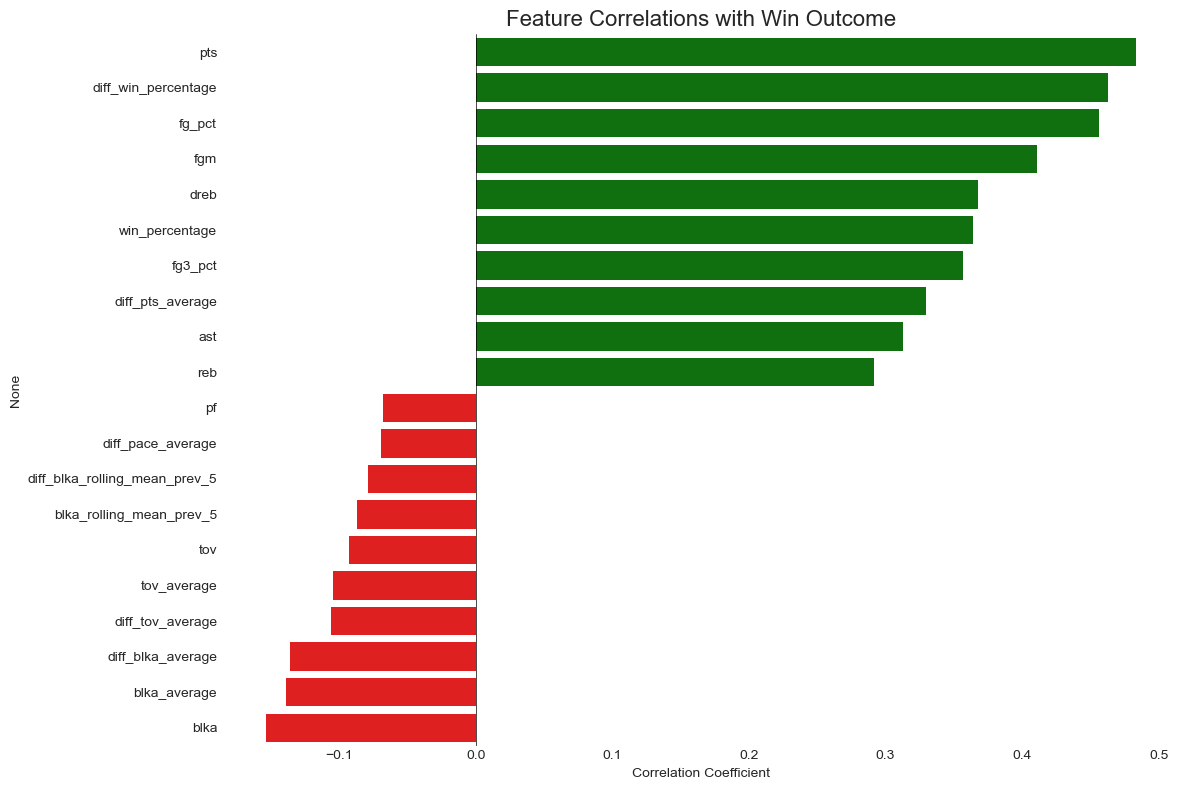

In [15]:
# Correlation Analysis
print("\n" + "="*80)
print("CORRELATION WITH WIN")
print("="*80)

correlations = in_game_df[numeric_cols + ['win']].corr()['win'].sort_values(ascending=False)
print("\nFeatures most positively correlated with winning:")
print(correlations.head(11)[1:].round(4))  # Skip win itself

print("\nFeatures most negatively correlated with winning:")
print(correlations.tail(10).round(4))

# Visualize top correlations
fig, ax = plt.subplots(figsize=(12, 8))  # Get figure and axes objects

# Set transparent backgrounds
fig.patch.set_alpha(0)   # Figure background transparent
ax.patch.set_alpha(0)    # Axes background transparent

top_corr = pd.concat([correlations.head(11)[1:], correlations.tail(10)])
colors = ['green' if x > 0 else 'red' for x in top_corr.values]
sns.barplot(x=top_corr.values, y=top_corr.index, palette=colors, ax=ax)
ax.set_title('Feature Correlations with Win Outcome', fontsize=16)
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()

# Save with transparency
plt.savefig('correlation_-bar_plot.png', transparent=True)

plt.show()




CORRELATION HEATMAP - TOP FEATURES


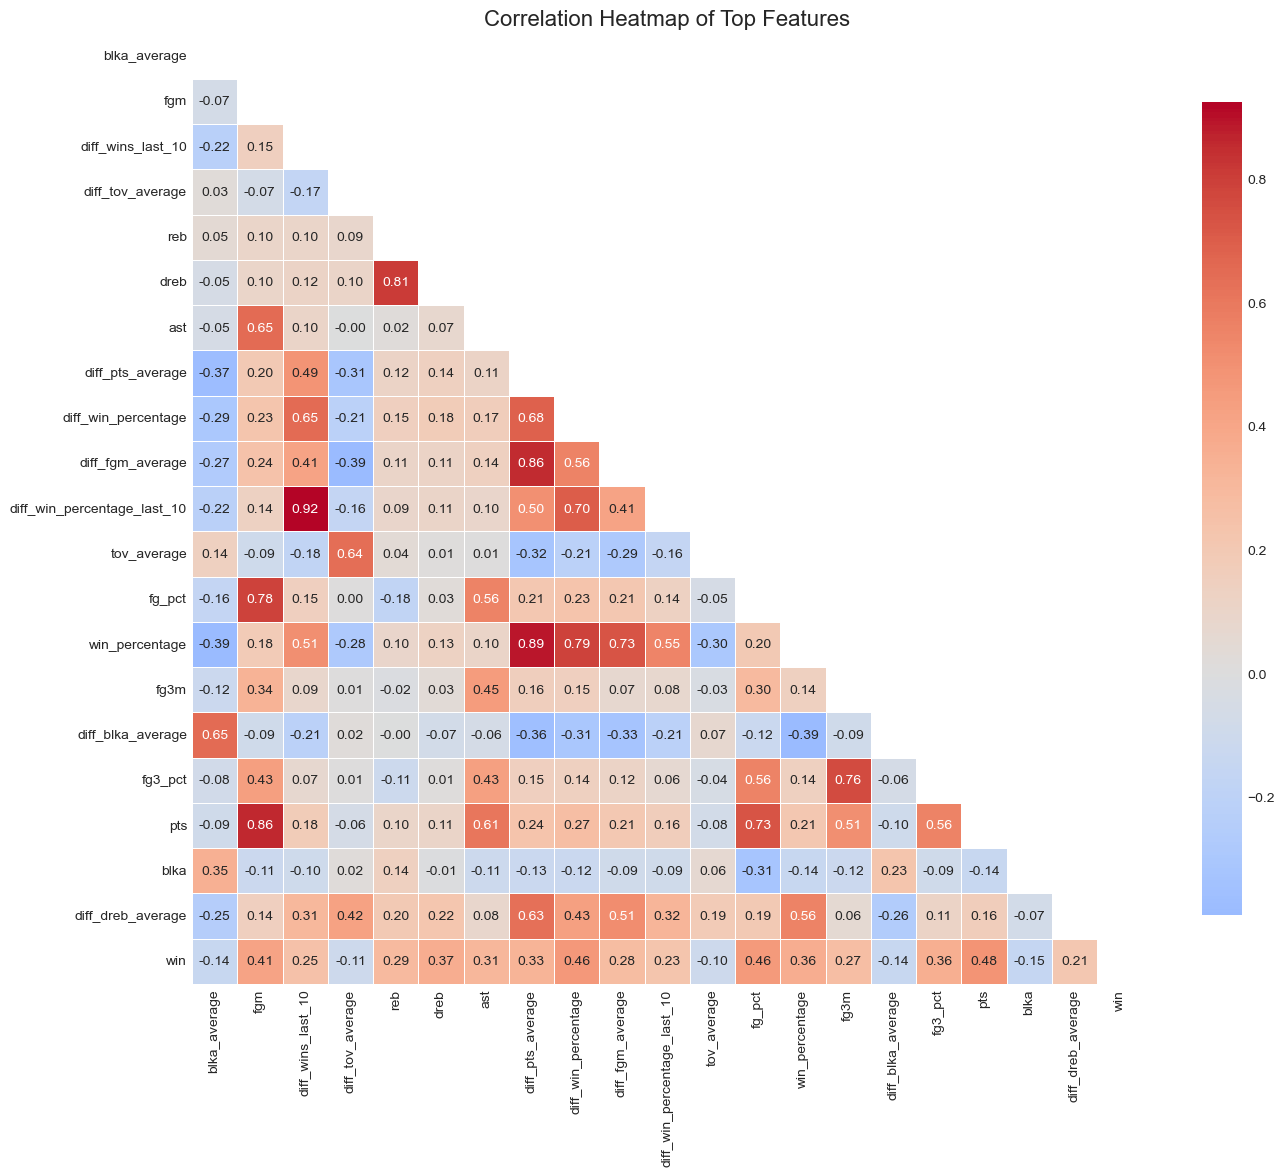

In [16]:
# Correlation Heatmap (for top features)
print("\n" + "="*80)
print("CORRELATION HEATMAP - TOP FEATURES")
print("="*80)

# Select top features based on correlation with win
top_features = correlations.head(16)[1:].index.tolist() + correlations.tail(5).index.tolist()
top_features = list(set(top_features))  # Remove duplicates

# Create figure with explicit reference
fig = plt.figure(figsize=(14, 12))
fig.patch.set_alpha(0)  # Make figure background transparent

# Compute correlation matrix and mask
corr_matrix = in_game_df[top_features + ['win']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw heatmap and get axes
ax = sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                 cmap='coolwarm', center=0, square=True,
                 linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.patch.set_alpha(0)  # Make axes background transparent

# Add title
plt.title('Correlation Heatmap of Top Features', fontsize=16)
plt.tight_layout()

# To save with transparency
plt.savefig('heatmap.png', transparent=True)

plt.show()


In [17]:
print("="*80)
print("OUTLIER ANALYSIS WITH BOX PLOTS")
print("="*80)

# Select key statistics for outlier analysis
key_stats = ['pts', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'tov', 
 'stl', 'blk', 'blka', 'pf', 'pfd', 'pace', 'poss','days_rest']
available_stats = [stat for stat in key_stats if stat in in_game_df.columns]

print(f"\nAnalyzing {len(available_stats)} key statistics")

# 1. Function to detect outliers using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# 2. Function to detect outliers using Z-score method
def detect_outliers_zscore(df, column, threshold=3):
    z_scores = np.abs(stats.zscore(df[column].dropna()))
    outliers = df.iloc[np.where(z_scores > threshold)[0]]
    return outliers

# 3. Create comprehensive outlier analysis
print("\n" + "="*80)
print("OUTLIER DETECTION RESULTS")
print("="*80)

outlier_summary = []

for stat in available_stats:
    # IQR method
    outliers_iqr, lower, upper = detect_outliers_iqr(in_game_df, stat)
    
    # Z-score method
    outliers_zscore = detect_outliers_zscore(in_game_df, stat)
    
    # Calculate statistics
    stat_mean = in_game_df[stat].mean()
    stat_std = in_game_df[stat].std()
    stat_min = in_game_df[stat].min()
    stat_max = in_game_df[stat].max()
    
    # Store summary
    outlier_summary.append({
        'Statistic': stat,
        'Mean': stat_mean,
        'Std': stat_std,
        'Min': stat_min,
        'Max': stat_max,
        'IQR_Outliers': len(outliers_iqr),
        'IQR_Outlier_%': (len(outliers_iqr) / len(in_game_df)) * 100,
        'ZScore_Outliers': len(outliers_zscore),
        'ZScore_Outlier_%': (len(outliers_zscore) / len(in_game_df)) * 100,
        'Lower_Bound': lower,
        'Upper_Bound': upper
    })
    
    # Print significant findings
    if len(outliers_iqr) > 0:
        print(f"\n📊 {stat.upper()} - Outliers found:")
        print(f"   Range: {stat_min:.2f} to {stat_max:.2f}")
        print(f"   Mean: {stat_mean:.2f} ± {stat_std:.2f}")
        print(f"   IQR outliers: {len(outliers_iqr)} ({len(outliers_iqr)/len(in_game_df)*100:.2f}%)")
        print(f"   Normal range: [{lower:.2f}, {upper:.2f}]")
        
        # Check if outliers are more likely to be wins
        if len(outliers_iqr) > 0:
            outlier_win_rate = outliers_iqr['win'].mean()
            normal_data = in_game_df[~in_game_df.index.isin(outliers_iqr.index)]
            normal_win_rate = normal_data['win'].mean()
            print(f"   Outlier win rate: {outlier_win_rate:.2%}")
            print(f"   Normal win rate: {normal_win_rate:.2%}")
            print(f"   Impact: {(outlier_win_rate - normal_win_rate)*100:+.1f}%")


OUTLIER ANALYSIS WITH BOX PLOTS

Analyzing 23 key statistics

OUTLIER DETECTION RESULTS

📊 PTS - Outliers found:
   Range: 66.00 to 176.00
   Mean: 113.40 ± 12.64
   IQR outliers: 87 (0.64%)
   Normal range: [79.50, 147.50]
   Outlier win rate: 55.17%
   Normal win rate: 49.97%
   Impact: +5.2%

📊 FGM - Outliers found:
   Range: 22.00 to 65.00
   Mean: 41.58 ± 5.25
   IQR outliers: 103 (0.76%)
   Normal range: [27.50, 55.50]
   Outlier win rate: 70.87%
   Normal win rate: 49.84%
   Impact: +21.0%

📊 FGA - Outliers found:
   Range: 64.00 to 122.00
   Mean: 88.67 ± 7.09
   IQR outliers: 204 (1.50%)
   Normal range: [70.50, 106.50]
   Outlier win rate: 43.14%
   Normal win rate: 50.10%
   Impact: -7.0%

📊 FG_PCT - Outliers found:
   Range: 0.28 to 0.69
   Mean: 0.47 ± 0.05
   IQR outliers: 78 (0.57%)
   Normal range: [0.32, 0.62]
   Outlier win rate: 69.23%
   Normal win rate: 49.89%
   Impact: +19.3%

📊 FG3M - Outliers found:
   Range: 2.00 to 29.00
   Mean: 12.83 ± 3.92
   IQR outliers:

In [18]:
# Create summary dataframe
outlier_df = pd.DataFrame(outlier_summary)
print("\n" + "="*80)
print("OUTLIER SUMMARY TABLE")
print("="*80)
print(outlier_df.round(2).to_string(index=False))


OUTLIER SUMMARY TABLE
Statistic   Mean   Std   Min    Max  IQR_Outliers  IQR_Outlier_%  ZScore_Outliers  ZScore_Outlier_%  Lower_Bound  Upper_Bound
      pts 113.40 12.64 66.00 176.00            87           0.64               37              0.27        79.50       147.50
      fgm  41.58  5.25 22.00  65.00           103           0.76               35              0.26        27.50        55.50
      fga  88.67  7.09 64.00 122.00           204           1.50               78              0.57        70.50       106.50
   fg_pct   0.47  0.05  0.28   0.69            78           0.57               41              0.30         0.32         0.62
     fg3m  12.83  3.92  2.00  29.00           179           1.32               53              0.39         2.50        22.50
     fg3a  35.55  6.96 10.00  65.00           139           1.02               42              0.31        17.50        53.50
  fg3_pct   0.36  0.08  0.07   0.68           113           0.83               38              

In [25]:
def count_outliers(df, column, group_col=None, group_value=None):
    """
    Count outliers above and below the box for a given column.
    Outliers defined as values > Q3 + 1.5*IQR or < Q1 - 1.5*IQR.
    """
    if group_col is not None and group_value is not None:
        data = df[df[group_col] == group_value][column].dropna()
    else:
        data = df[column].dropna()
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    below = (data < lower_bound).sum()
    above = (data > upper_bound).sum()
    total_outliers = below + above
    
    return {
        'total': len(data),
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outliers_below': below,
        'outliers_above': above,
        'total_outliers': total_outliers,
        'outlier_percentage': (total_outliers / len(data)) * 100
    }

# Usage for 'poss' column
print("Overall poss outliers:")
overall = count_outliers(in_game_df, 'poss')
print(f"Total observations: {overall['total']}")
print(f"Outliers below: {overall['outliers_below']}")
print(f"Outliers above: {overall['outliers_above']}")
print(f"Total outliers: {overall['total_outliers']} ({overall['outlier_percentage']:.2f}%)")


Overall poss outliers:
Total observations: 13596
Outliers below: 44
Outliers above: 268
Total outliers: 312 (2.29%)



CREATING BOX PLOTS


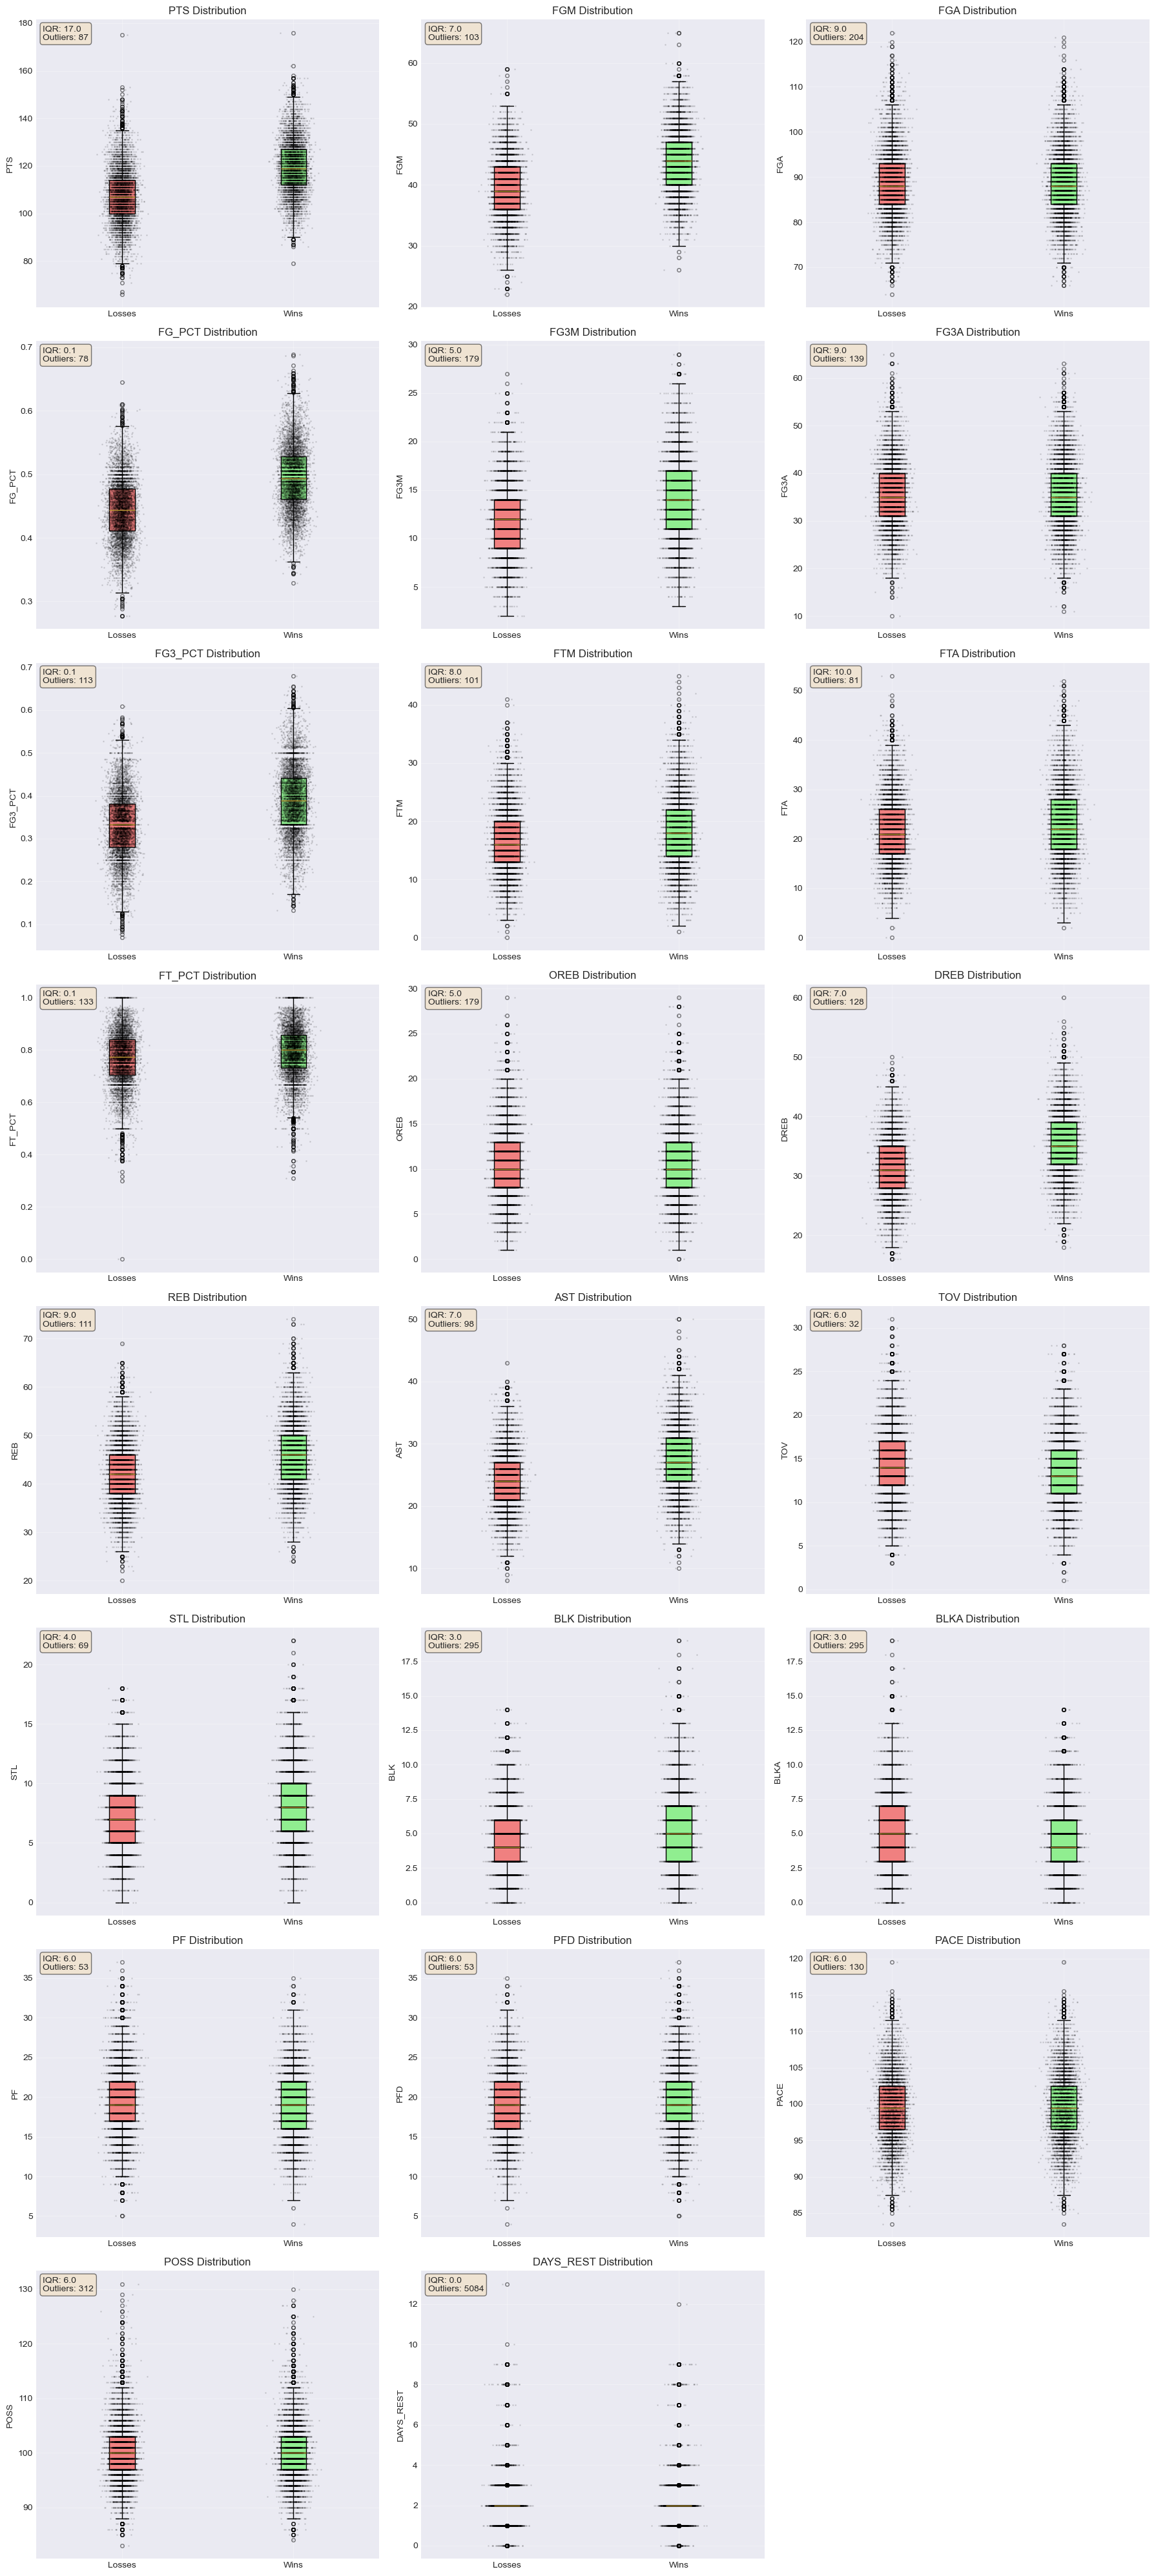

In [19]:
# Create box plots for all key statistics
print("\n" + "="*80)
print("CREATING BOX PLOTS")
print("="*80)

# Determine grid size for subplots
n_stats = len(available_stats)
n_cols = 3
n_rows = (n_stats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))


# Flatten axes array for easy iteration
if n_rows > 1:
    axes = axes.flatten()
else:
    axes = [axes] if n_cols == 1 else axes

# Create box plots
for idx, stat in enumerate(available_stats):
    if idx < len(axes):
        # Create box plot split by win/loss
        data_to_plot = [
            in_game_df[in_game_df['win'] == 0][stat].dropna(),
            in_game_df[in_game_df['win'] == 1][stat].dropna()
        ]
        
        bp = axes[idx].boxplot(data_to_plot, labels=['Losses', 'Wins'], 
                               patch_artist=True, showfliers=True)
        
        # Color the boxes
        bp['boxes'][0].set_facecolor('lightcoral')
        bp['boxes'][1].set_facecolor('lightgreen')
        
        # Color the outliers
        for flier in bp['fliers']:
            flier.set(marker='o', markersize=4, alpha=0.5)
        
        # Add individual points (jittered) for better visualization
        for i, data in enumerate(data_to_plot):
            y = data
            x = np.random.normal(i+1, 0.04, size=len(y))
            axes[idx].plot(x, y, 'k.', alpha=0.1, markersize=2)
        
        # Add statistics as text
        q1 = in_game_df[stat].quantile(0.25)
        q3 = in_game_df[stat].quantile(0.75)
        iqr = q3 - q1
        axes[idx].text(0.02, 0.98, f'IQR: {iqr:.1f}\nOutliers: {outlier_df.iloc[idx]["IQR_Outliers"]:.0f}', 
                      transform=axes[idx].transAxes, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        axes[idx].set_title(f'{stat.upper()} Distribution', fontsize=12)
        axes[idx].set_ylabel(stat.upper())
        axes[idx].grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(len(available_stats), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

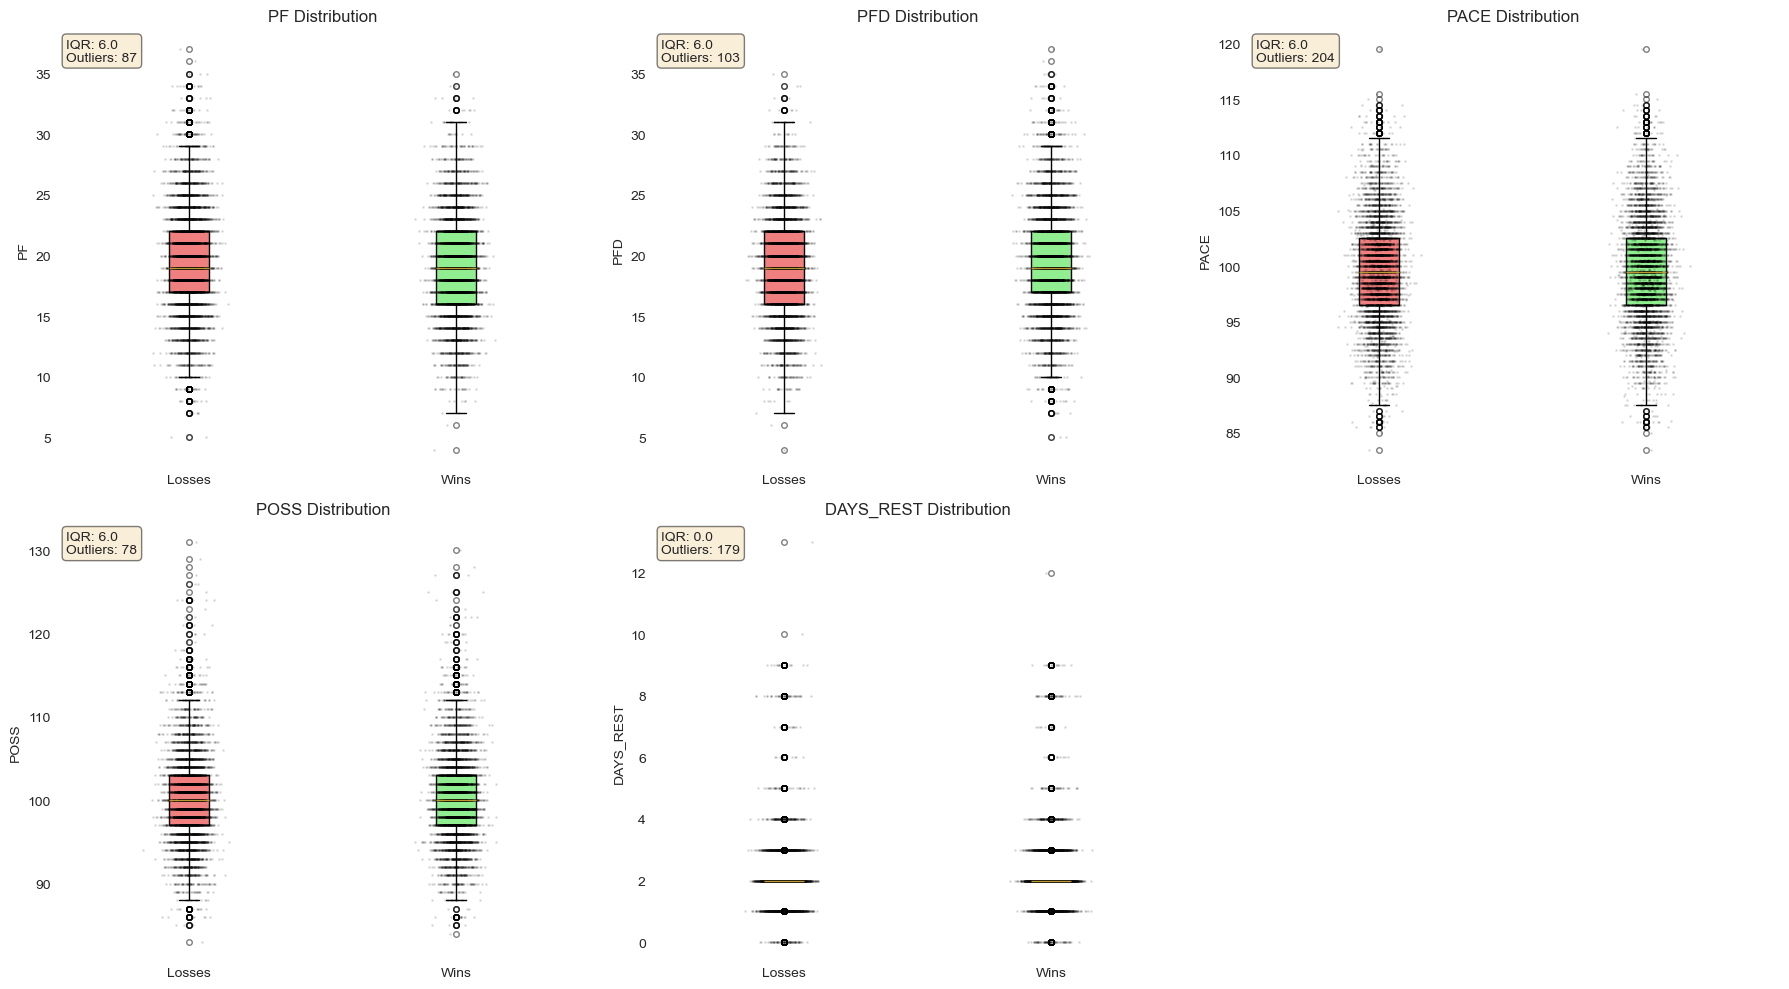

In [21]:
# Select the last 5 statistics
last_five_stats = available_stats[-5:]  # Adjust if you need a different selection

# Determine grid size for subplots
n_stats = len(last_five_stats)
n_cols = 3
n_rows = (n_stats + n_cols - 1) // n_cols

# Create figure with transparency
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
fig.patch.set_alpha(0)  # Make figure background transparent

# Flatten axes array for easy iteration
if n_rows > 1:
    axes = axes.flatten()
else:
    axes = [axes] if n_cols == 1 else axes

# Create box plots for each selected statistic
for idx, stat in enumerate(last_five_stats):
    if idx < len(axes):
        # Prepare data split by win/loss
        data_to_plot = [
            in_game_df[in_game_df['win'] == 0][stat].dropna(),
            in_game_df[in_game_df['win'] == 1][stat].dropna()
        ]
        
        # Create boxplot with transparent axes background
        bp = axes[idx].boxplot(data_to_plot, labels=['Losses', 'Wins'], 
                               patch_artist=True, showfliers=True)
        
        # Set box colors
        bp['boxes'][0].set_facecolor('lightcoral')
        bp['boxes'][1].set_facecolor('lightgreen')
        
        # Style outliers
        for flier in bp['fliers']:
            flier.set(marker='o', markersize=4, alpha=0.5)
        
        # Add jittered individual points
        for i, data in enumerate(data_to_plot):
            y = data
            x = np.random.normal(i+1, 0.04, size=len(y))
            axes[idx].plot(x, y, 'k.', alpha=0.1, markersize=2)
        
        # Add statistics text box
        q1 = in_game_df[stat].quantile(0.25)
        q3 = in_game_df[stat].quantile(0.75)
        iqr = q3 - q1
        # outlier_df should be defined previously; if not, adjust or remove
        axes[idx].text(0.02, 0.98, f'IQR: {iqr:.1f}\nOutliers: {outlier_df.iloc[idx]["IQR_Outliers"]:.0f}', 
                      transform=axes[idx].transAxes, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        axes[idx].set_title(f'{stat.upper()} Distribution', fontsize=12)
        axes[idx].set_ylabel(stat.upper())
        axes[idx].grid(True, alpha=0.3)
        
        # Make each subplot's background transparent
        axes[idx].patch.set_alpha(0)

# Hide any empty subplots
for idx in range(len(last_five_stats), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()

# Save the figure with transparency
plt.savefig('last_five_outlier_boxplots.png', transparent=True)

plt.show()


BOX PLOTS: DIFFERENTIAL STATISTICS


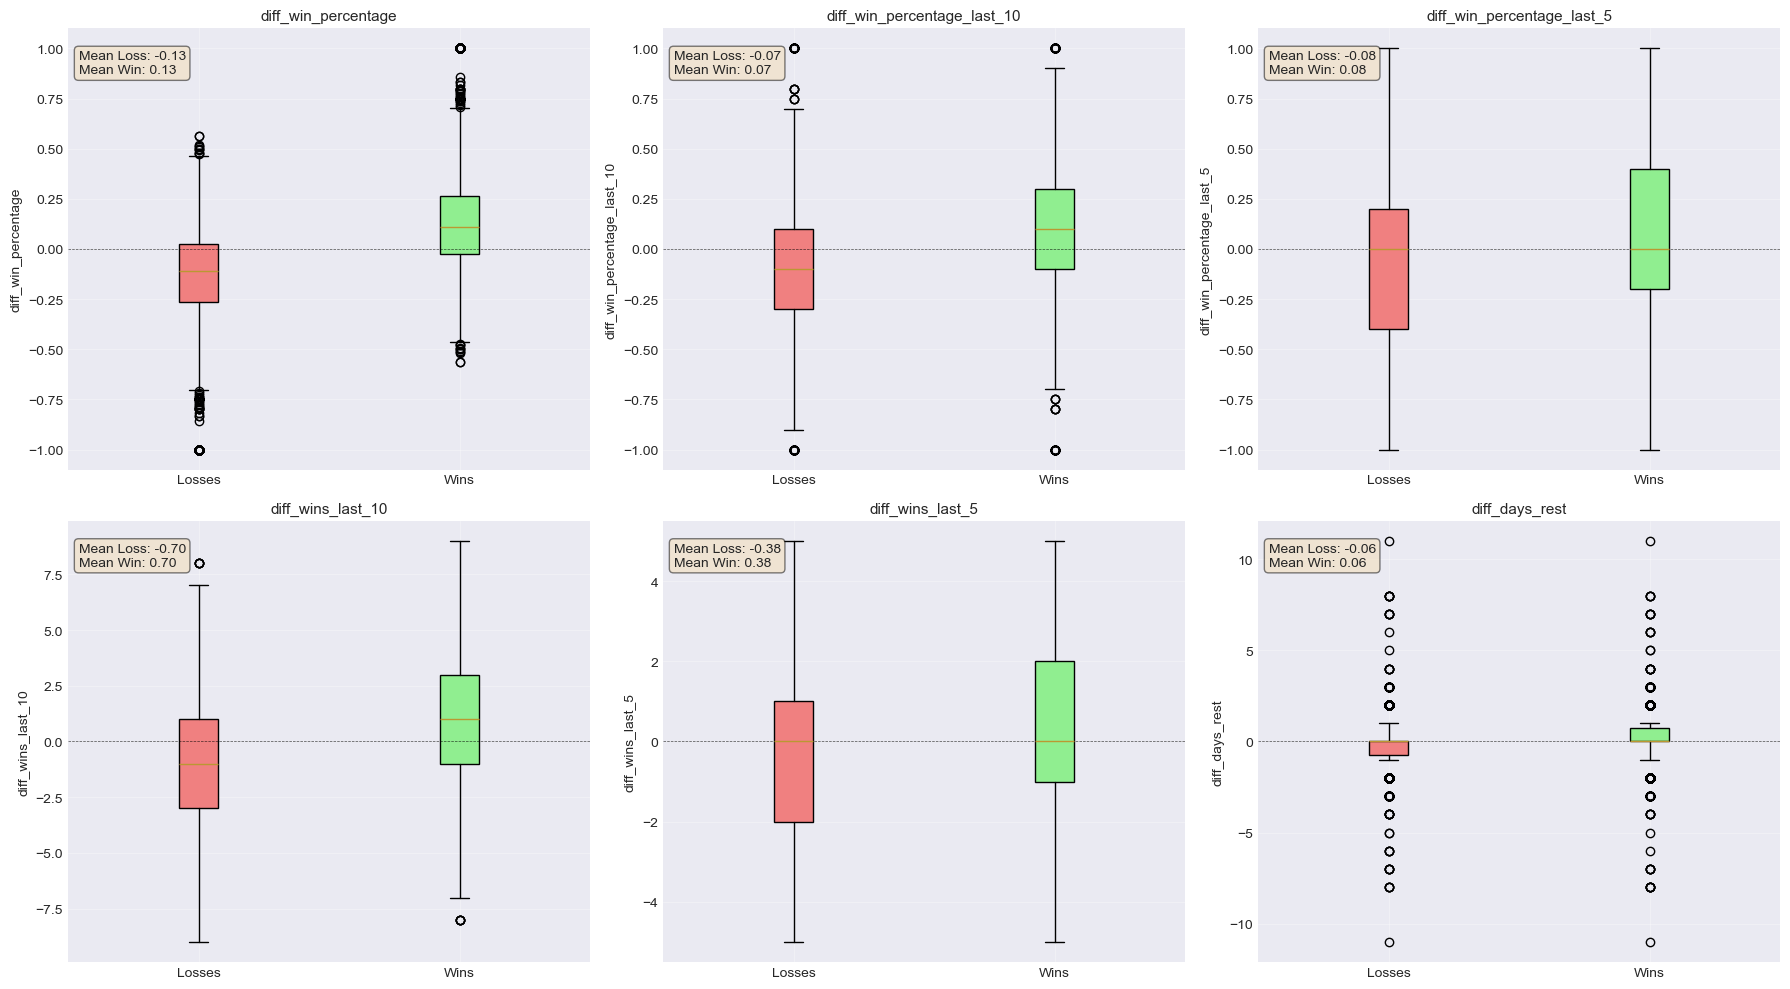

In [18]:
#  Separate box plots for differential stats
print("\n" + "="*80)
print("BOX PLOTS: DIFFERENTIAL STATISTICS")
print("="*80)

diff_stats = [col for col in in_game_df.columns if col.startswith('diff_') and 'average' not in col and 'rolling' not in col]

if diff_stats:
    n_diff = len(diff_stats)
    n_rows = (n_diff + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
    
    
    if n_rows > 1:
        axes = axes.flatten()
    
    for idx, stat in enumerate(diff_stats):
        if idx < len(axes):
            data_to_plot = [
                in_game_df[in_game_df['win'] == 0][stat].dropna(),
                in_game_df[in_game_df['win'] == 1][stat].dropna()
            ]
            
            bp = axes[idx].boxplot(data_to_plot, labels=['Losses', 'Wins'],
                                   patch_artist=True, showfliers=True)
            
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightgreen')
            
            # Add horizontal line at zero
            axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.7)
            
            # Add mean values
            mean_loss = in_game_df[in_game_df['win'] == 0][stat].mean()
            mean_win = in_game_df[in_game_df['win'] == 1][stat].mean()
            axes[idx].text(0.02, 0.95, f'Mean Loss: {mean_loss:.2f}\nMean Win: {mean_win:.2f}',
                          transform=axes[idx].transAxes, verticalalignment='top',
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            axes[idx].set_title(f'{stat}', fontsize=11)
            axes[idx].set_ylabel(stat)
            axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(diff_stats), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()


BOX PLOTS: ROLLING AVERAGES


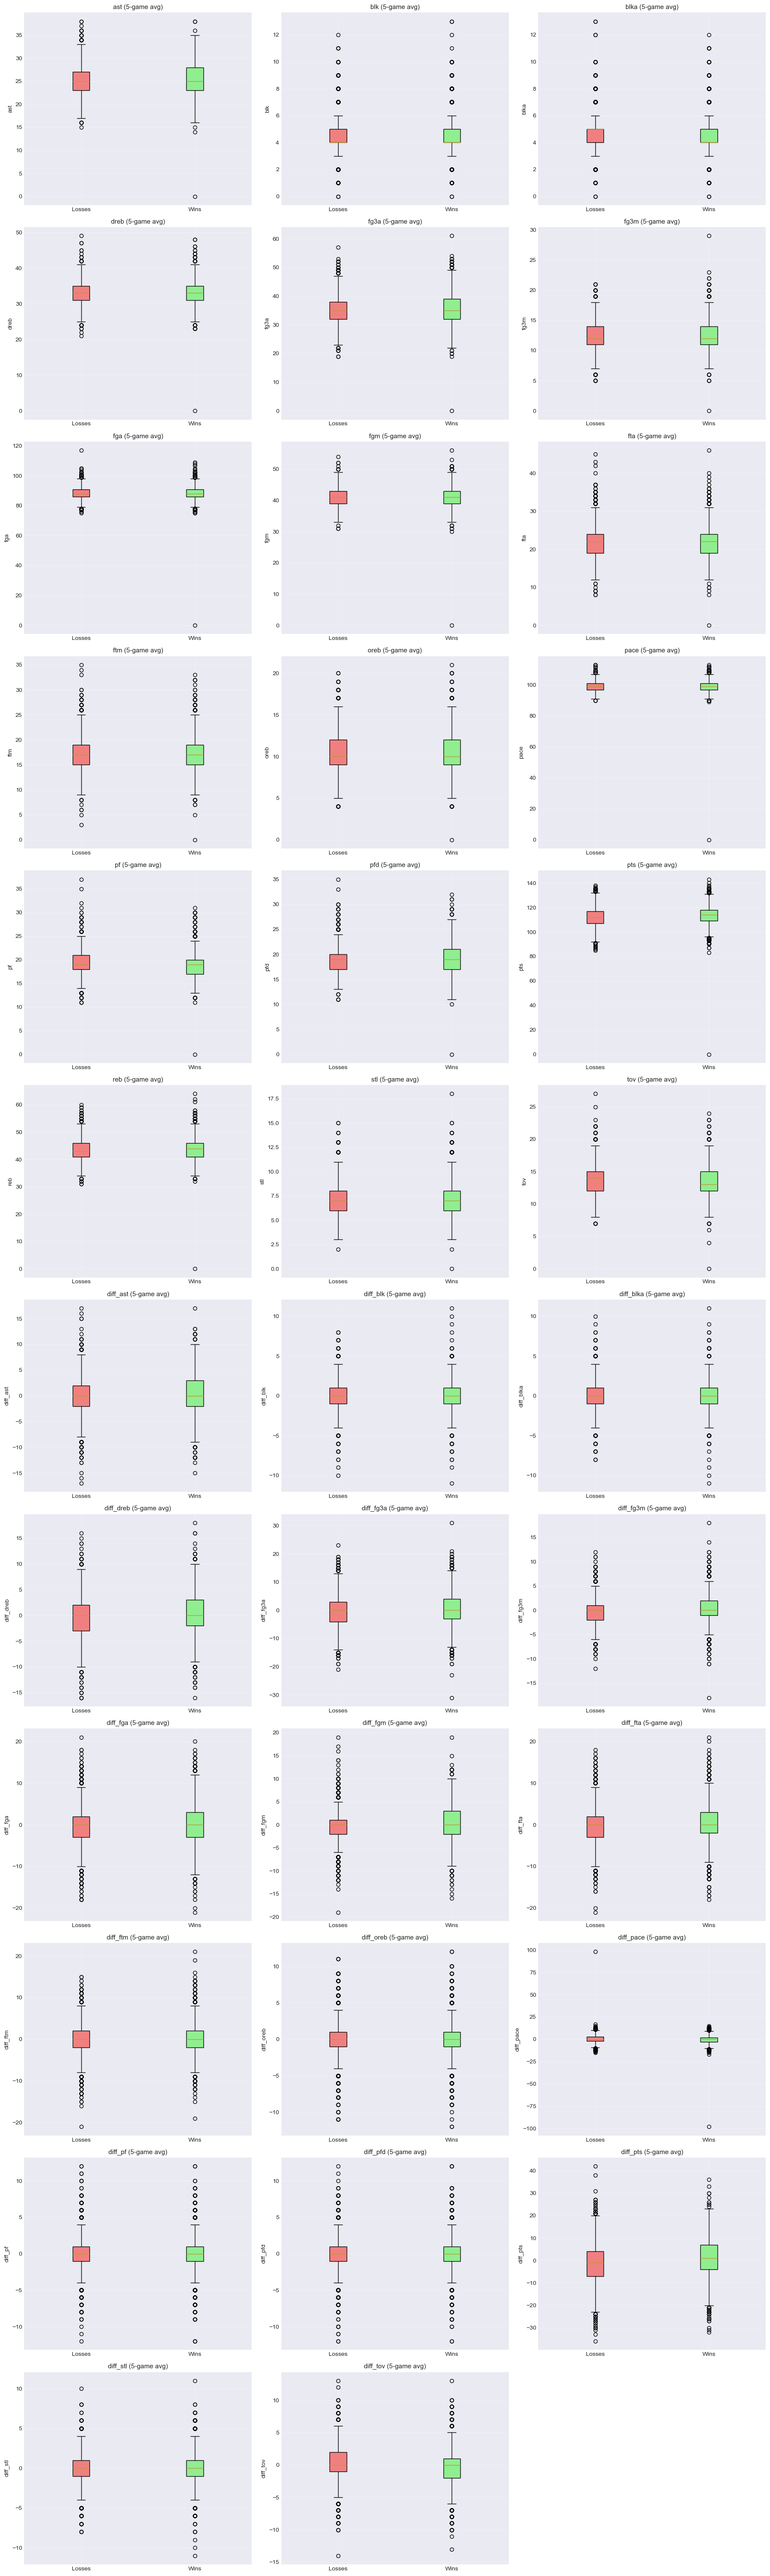

In [19]:
#  Rolling stats box plots
print("\n" + "="*80)
print("BOX PLOTS: ROLLING AVERAGES")
print("="*80)

rolling_stats = [col for col in in_game_df.columns if 'rolling_mean_prev_5' in col]

if rolling_stats:
    n_rolling = len(rolling_stats)
    n_rows = (n_rolling + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
    
    
    if n_rows > 1:
        axes = axes.flatten()
    
    for idx, stat in enumerate(rolling_stats):
        if idx < len(axes):
            data_to_plot = [
                in_game_df[in_game_df['win'] == 0][stat].dropna(),
                in_game_df[in_game_df['win'] == 1][stat].dropna()
            ]
            
            bp = axes[idx].boxplot(data_to_plot, labels=['Losses', 'Wins'],
                                   patch_artist=True, showfliers=True)
            
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightgreen')
            
            short_name = stat.replace('_rolling_mean_prev_5', '')
            axes[idx].set_title(f'{short_name} (5-game avg)', fontsize=11)
            axes[idx].set_ylabel(short_name)
            axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(rolling_stats), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()


POINTS ANALYSIS

📊 Basic Points Statistics:
Average points per game: 113.40
Median points: 113.00
Std deviation: 12.64
Min points: 66.00
Max points: 176.00

📈 Points by Game Outcome:
Winning teams average: 119.52
Losing teams average: 107.28
Difference: 12.23


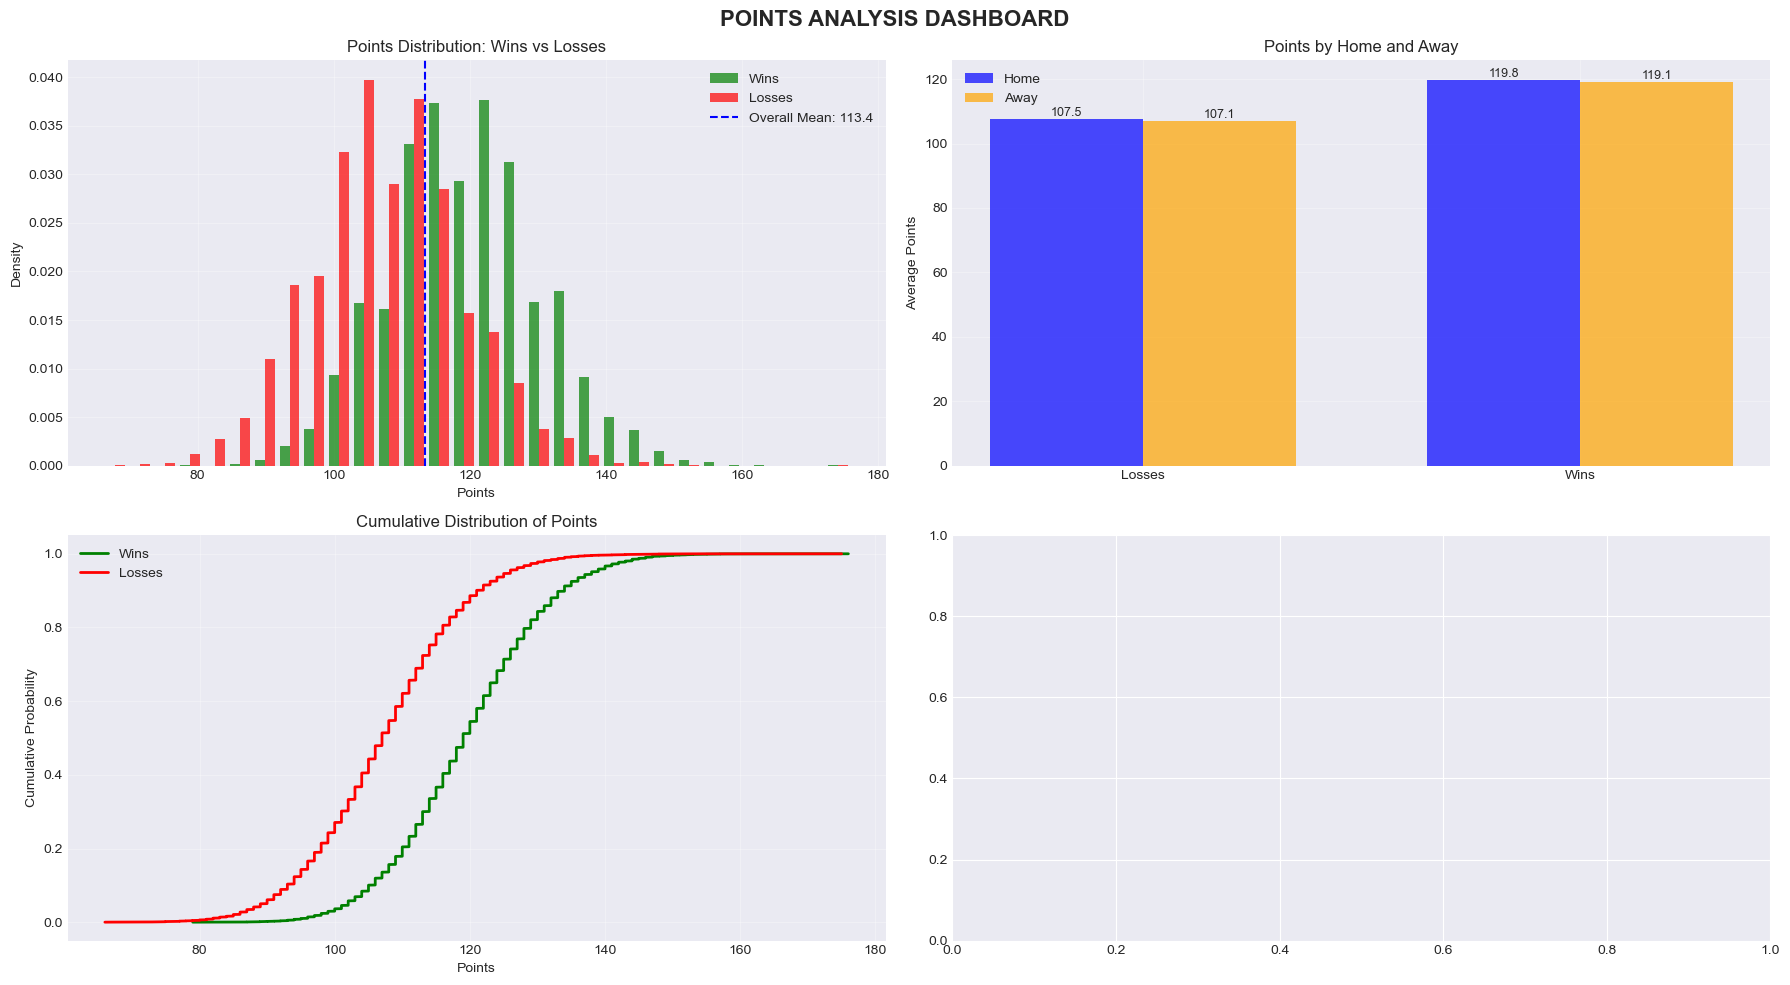

In [22]:
# POINTS ANALYSIS

print("\n" + "="*80)
print("POINTS ANALYSIS")
print("="*80)

# Basic points statistics
print("\n📊 Basic Points Statistics:")
print(f"Average points per game: {in_game_df['pts'].mean():.2f}")
print(f"Median points: {in_game_df['pts'].median():.2f}")
print(f"Std deviation: {in_game_df['pts'].std():.2f}")
print(f"Min points: {in_game_df['pts'].min():.2f}")
print(f"Max points: {in_game_df['pts'].max():.2f}")

# Points by game outcome
print("\n📈 Points by Game Outcome:")
print(f"Winning teams average: {in_game_df[in_game_df['win']==1]['pts'].mean():.2f}")
print(f"Losing teams average: {in_game_df[in_game_df['win']==0]['pts'].mean():.2f}")
print(f"Difference: {in_game_df[in_game_df['win']==1]['pts'].mean() - in_game_df[in_game_df['win']==0]['pts'].mean():.2f}")

# Points distribution
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1. Points distribution histogram
ax1 = axes[0, 0]
ax1.hist([in_game_df[in_game_df['win']==1]['pts'], 
          in_game_df[in_game_df['win']==0]['pts']], 
         bins=30, label=['Wins', 'Losses'], color=['green', 'red'], alpha=0.7, density=True)
ax1.axvline(in_game_df['pts'].mean(), color='blue', linestyle='--', label=f'Overall Mean: {in_game_df["pts"].mean():.1f}')
ax1.set_xlabel('Points')
ax1.set_ylabel('Density')
ax1.set_title('Points Distribution: Wins vs Losses')
ax1.legend()
ax1.grid(True, alpha=0.3)


# 2. Points by home/away
ax5 = axes[0, 1]
home_pts = in_game_df[in_game_df['is_home']==1].groupby('win')['pts'].mean()
away_pts = in_game_df[in_game_df['is_home']==0].groupby('win')['pts'].mean()

x = np.arange(2)
width = 0.35
bars1 = ax5.bar(x - width/2, [home_pts.get(0, 0), home_pts.get(1, 0)], width, label='Home', color='blue', alpha=0.7)
bars2 = ax5.bar(x + width/2, [away_pts.get(0, 0), away_pts.get(1, 0)], width, label='Away', color='orange', alpha=0.7)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}', ha='center', va='bottom', fontsize=9)

ax5.set_xticks(x)
ax5.set_xticklabels(['Losses', 'Wins'])
ax5.set_ylabel('Average Points')
ax5.set_title('Points by Home and Away')
ax5.legend()
ax5.grid(True, alpha=0.3)


# 3. Points cumulative distribution
ax6 = axes[1, 0]
for outcome, color in [(1, 'green'), (0, 'red')]:
    sorted_pts = np.sort(in_game_df[in_game_df['win']==outcome]['pts'].dropna())
    y = np.arange(1, len(sorted_pts)+1) / len(sorted_pts)
    ax6.plot(sorted_pts, y, label=f'{"Wins" if outcome else "Losses"}', color=color, linewidth=2)
ax6.set_xlabel('Points')
ax6.set_ylabel('Cumulative Probability')
ax6.set_title('Cumulative Distribution of Points')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.suptitle('POINTS ANALYSIS DASHBOARD', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------------
# 1. Points distribution histogram (Wins vs Losses)
# ----------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(9, 5))
fig1.patch.set_alpha(0)      # transparent figure background
ax1.patch.set_alpha(0)       # transparent axes background

# Histogram
ax1.hist([in_game_df[in_game_df['win']==1]['pts'], 
          in_game_df[in_game_df['win']==0]['pts']], 
         bins=30, label=['Wins', 'Losses'], color=['green', 'red'], 
         alpha=0.7, density=True)

# Overall mean line
mean_pts = in_game_df['pts'].mean()
ax1.axvline(mean_pts, color='blue', linestyle='--', 
            label=f'Overall Mean: {mean_pts:.1f}')

ax1.set_xlabel('Points')
ax1.set_ylabel('Density')
ax1.set_title('Points Distribution: Wins vs Losses')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('points_hist.png', transparent=True)   # save with transparency
plt.close(fig1)   # close to free memory

# ----------------------------------------------------------------------
# 2. Points by home/away (bar chart)
# ----------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(9, 5))
fig2.patch.set_alpha(0)
ax2.patch.set_alpha(0)

# Compute averages
home_pts = in_game_df[in_game_df['is_home']==1].groupby('win')['pts'].mean()
away_pts = in_game_df[in_game_df['is_home']==0].groupby('win')['pts'].mean()

x = np.arange(2)   # [0,1] for Losses, Wins
width = 0.35

bars1 = ax2.bar(x - width/2, [home_pts.get(0, 0), home_pts.get(1, 0)], 
                width, label='Home', color='blue', alpha=0.7)
bars2 = ax2.bar(x + width/2, [away_pts.get(0, 0), away_pts.get(1, 0)], 
                width, label='Away', color='orange', alpha=0.7)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}', ha='center', va='bottom', fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(['Losses', 'Wins'])
ax2.set_ylabel('Average Points')
ax2.set_title('Points by Home and Away')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('points_home_away.png', transparent=True)
plt.close(fig2)

# ----------------------------------------------------------------------
# 3. Cumulative distribution of points
# ----------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(9, 5))
fig3.patch.set_alpha(0)
ax3.patch.set_alpha(0)

for outcome, color in [(1, 'green'), (0, 'red')]:
    sorted_pts = np.sort(in_game_df[in_game_df['win']==outcome]['pts'].dropna())
    y = np.arange(1, len(sorted_pts)+1) / len(sorted_pts)
    ax3.plot(sorted_pts, y, label=f'{"Wins" if outcome else "Losses"}', 
             color=color, linewidth=2)

ax3.set_xlabel('Points')
ax3.set_ylabel('Cumulative Probability')
ax3.set_title('Cumulative Distribution of Points')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('points_cumulative.png', transparent=True)
plt.close(fig3)


PART 2: FIELD GOAL ANALYSIS

📊 Points Breakdown by Outcome:
Winners - 2PT: 59.7, 3PT: 41.7, Total: 101.4
Losers  - 2PT: 55.3, 3PT: 35.3, Total: 90.6


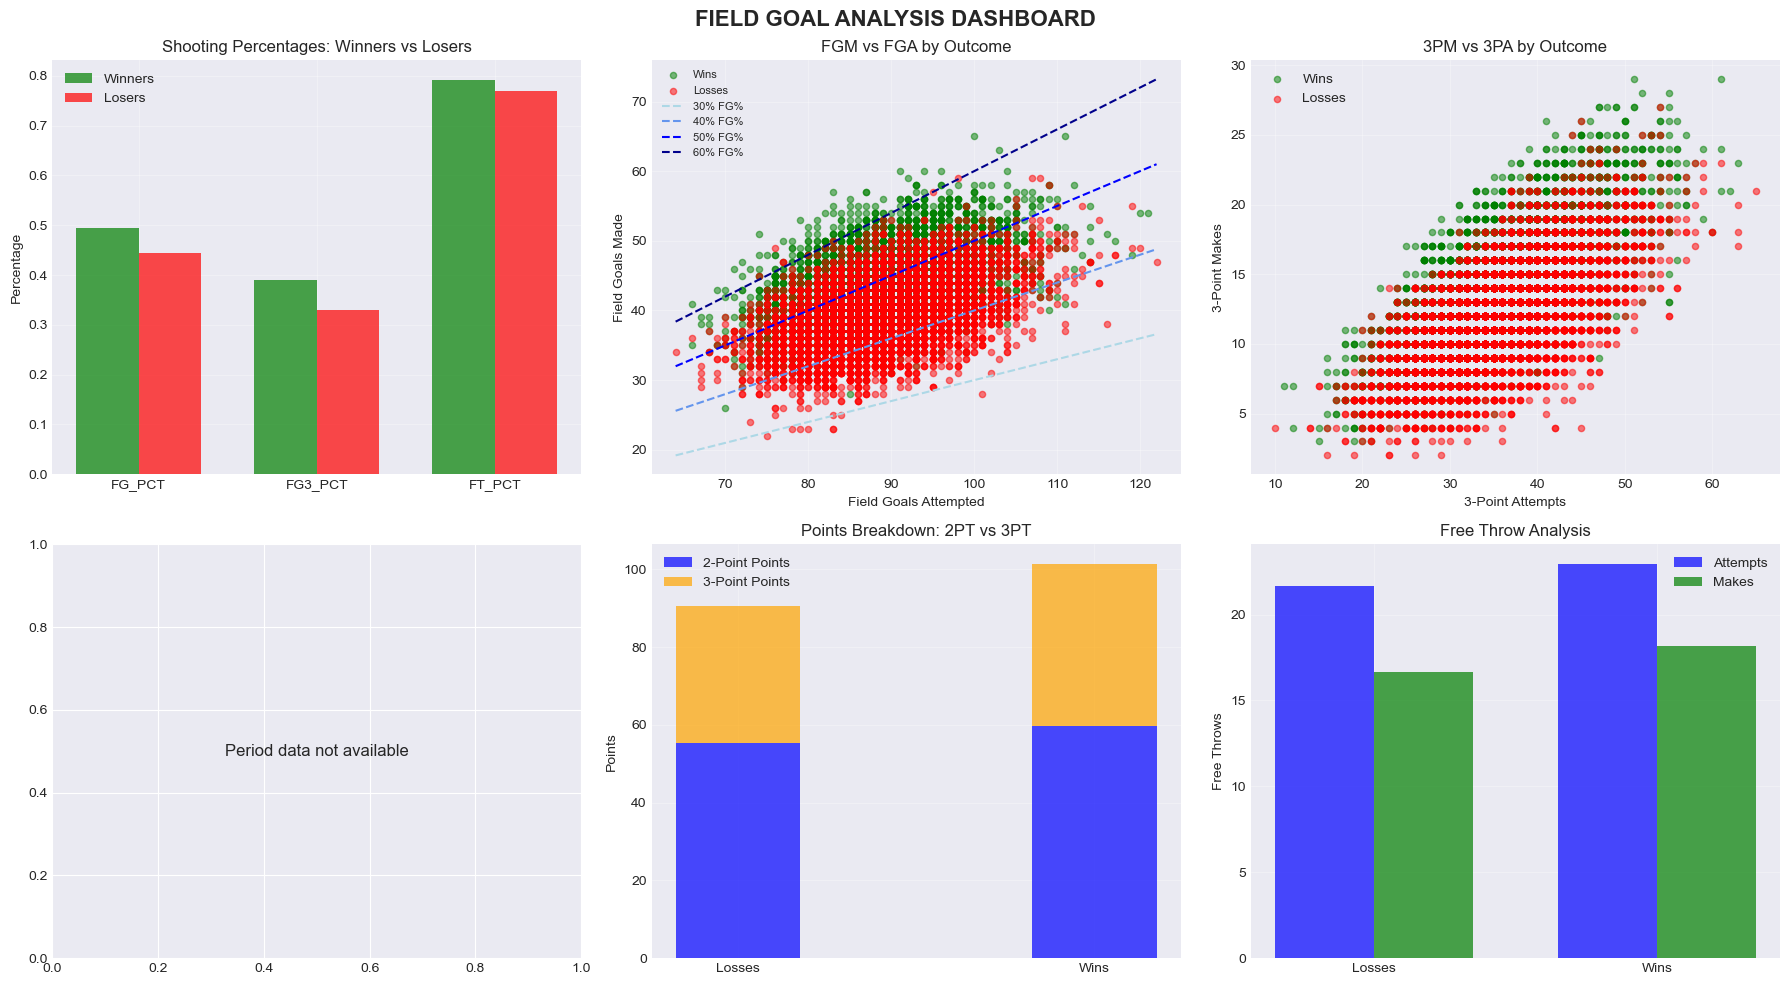

In [24]:
#  FIELD GOAL ANALYSIS

print("\n" + "="*80)
print("PART 2: FIELD GOAL ANALYSIS")
print("="*80)

# Shooting analysis visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Shooting percentages distribution
ax1 = axes[0, 0]
shooting_stats = ['fg_pct', 'fg3_pct', 'ft_pct']
shooting_data = []
for stat in shooting_stats:
    if stat in in_game_df.columns:
        shooting_data.append({
            'Stat': stat.upper(),
            'Winners': in_game_df[in_game_df['win']==1][stat].mean(),
            'Losers': in_game_df[in_game_df['win']==0][stat].mean()
        })

shooting_df = pd.DataFrame(shooting_data)
x = np.arange(len(shooting_df))
width = 0.35
ax1.bar(x - width/2, shooting_df['Winners'], width, label='Winners', color='green', alpha=0.7)
ax1.bar(x + width/2, shooting_df['Losers'], width, label='Losers', color='red', alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(shooting_df['Stat'])
ax1.set_ylabel('Percentage')
ax1.set_title('Shooting Percentages: Winners vs Losers')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Field goals made vs attempted
ax2 = axes[0, 1]
if 'fgm' in in_game_df.columns and 'fga' in in_game_df.columns:
    ax2.scatter(in_game_df[in_game_df['win']==1]['fga'], 
               in_game_df[in_game_df['win']==1]['fgm'], 
               alpha=0.5, label='Wins', color='green', s=20)
    ax2.scatter(in_game_df[in_game_df['win']==0]['fga'], 
               in_game_df[in_game_df['win']==0]['fgm'], 
               alpha=0.5, label='Losses', color='red', s=20)
    
    # Add efficiency lines with different colors and labels
    efficiencies = [0.3, 0.4, 0.5, 0.6]
    colors = ['lightblue', 'cornflowerblue', 'blue', 'darkblue']
    
    for eff, color in zip(efficiencies, colors):
        x_line = np.linspace(in_game_df['fga'].min(), in_game_df['fga'].max(), 10)
        y_line = eff * x_line
        ax2.plot(x_line, y_line, linestyle='--', color=color, 
                label=f'{eff:.0%} FG%', linewidth=1.5)
    
    ax2.set_xlabel('Field Goals Attempted')
    ax2.set_ylabel('Field Goals Made')
    ax2.set_title('FGM vs FGA by Outcome')
    ax2.legend(loc='best', fontsize=8)  # Adjust legend to fit all lines
    ax2.grid(True, alpha=0.3)




# 3. 3-Point analysis
ax3 = axes[0, 2]
if 'fg3m' in in_game_df.columns and 'fg3a' in in_game_df.columns:
    ax3.scatter(in_game_df[in_game_df['win']==1]['fg3a'], 
               in_game_df[in_game_df['win']==1]['fg3m'], 
               alpha=0.5, label='Wins', color='green', s=20)
    ax3.scatter(in_game_df[in_game_df['win']==0]['fg3a'], 
               in_game_df[in_game_df['win']==0]['fg3m'], 
               alpha=0.5, label='Losses', color='red', s=20)
    ax3.set_xlabel('3-Point Attempts')
    ax3.set_ylabel('3-Point Makes')
    ax3.set_title('3PM vs 3PA by Outcome')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 4. Shooting efficiency by quarter (if available)
ax4 = axes[1, 0]
fg_pct_cols = [col for col in in_game_df.columns if 'fg_pct_' in col]
if fg_pct_cols:
    fg_by_period = in_game_df[fg_pct_cols].mean()
    ax4.plot(range(len(fg_by_period)), fg_by_period.values, marker='o', linewidth=2, color='blue')
    ax4.set_xticks(range(len(fg_by_period)))
    ax4.set_xticklabels([col.replace('fg_pct_', '').upper() for col in fg_by_period.index])
    ax4.set_ylabel('Field Goal %')
    ax4.set_title('FG% by Period')
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Period data not available', ha='center', va='center', fontsize=12)

# 5. 2PT vs 3PT scoring 
ax5 = axes[1, 1]
if all(col in in_game_df.columns for col in ['fgm', 'fg3m', 'fga', 'fg3a']):
    # Calculate 2-point and 3-point points
    in_game_df['pts_2pt'] = (in_game_df['fgm'] - in_game_df['fg3m']) * 2
    in_game_df['pts_3pt'] = in_game_df['fg3m'] * 3
    
    # Group by win/loss
    pts_2pt_by_outcome = in_game_df.groupby('win')['pts_2pt'].mean()
    pts_3pt_by_outcome = in_game_df.groupby('win')['pts_3pt'].mean()
    
    # Create the stacked bar chart
    x_pos = [0, 1]
    ax5.bar(x_pos, pts_2pt_by_outcome.values, width=0.35, label='2-Point Points', color='blue', alpha=0.7)
    ax5.bar(x_pos, pts_3pt_by_outcome.values, width=0.35, bottom=pts_2pt_by_outcome.values, 
            label='3-Point Points', color='orange', alpha=0.7)
    
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(['Losses', 'Wins'])
    ax5.set_ylabel('Points')
    ax5.set_title('Points Breakdown: 2PT vs 3PT')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # Print the breakdown
    print("\n📊 Points Breakdown by Outcome:")
    print(f"Winners - 2PT: {pts_2pt_by_outcome[1]:.1f}, 3PT: {pts_3pt_by_outcome[1]:.1f}, Total: {pts_2pt_by_outcome[1] + pts_3pt_by_outcome[1]:.1f}")
    print(f"Losers  - 2PT: {pts_2pt_by_outcome[0]:.1f}, 3PT: {pts_3pt_by_outcome[0]:.1f}, Total: {pts_2pt_by_outcome[0] + pts_3pt_by_outcome[0]:.1f}")

# 6. Free throw analysis
ax6 = axes[1, 2]
if 'ftm' in in_game_df.columns and 'fta' in in_game_df.columns:
    ft_attempts_by_outcome = in_game_df.groupby('win')['fta'].mean()
    ft_makes_by_outcome = in_game_df.groupby('win')['ftm'].mean()
    
    x = np.arange(2)
    width = 0.35
    ax6.bar(x - width/2, ft_attempts_by_outcome.values, width, label='Attempts', color='blue', alpha=0.7)
    ax6.bar(x + width/2, ft_makes_by_outcome.values, width, label='Makes', color='green', alpha=0.7)
    ax6.set_xticks(x)
    ax6.set_xticklabels(['Losses', 'Wins'])
    ax6.set_ylabel('Free Throws')
    ax6.set_title('Free Throw Analysis')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

plt.suptitle('FIELD GOAL ANALYSIS DASHBOARD', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# ----------------------------------------------------------------------
# Plot 1: Shooting percentages distribution (bar chart)
# ----------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(9, 5))
fig1.patch.set_alpha(0)
ax1.patch.set_alpha(0)

shooting_stats = ['fg_pct', 'fg3_pct', 'ft_pct']
shooting_data = []
for stat in shooting_stats:
    if stat in in_game_df.columns:
        shooting_data.append({
            'Stat': stat.upper(),
            'Winners': in_game_df[in_game_df['win']==1][stat].mean(),
            'Losers': in_game_df[in_game_df['win']==0][stat].mean()
        })

shooting_df = pd.DataFrame(shooting_data)
x = np.arange(len(shooting_df))
width = 0.35
ax1.bar(x - width/2, shooting_df['Winners'], width, label='Winners', color='green', alpha=0.7)
ax1.bar(x + width/2, shooting_df['Losers'], width, label='Losers', color='red', alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(shooting_df['Stat'])
ax1.set_ylabel('Percentage')
ax1.set_title('Shooting Percentages: Winners vs Losers')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('shooting_percentages.png', transparent=True)
plt.close(fig1)

# ----------------------------------------------------------------------
# Plot 2: Field goals made vs attempted (with efficiency lines)
# ----------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(9, 5))
fig2.patch.set_alpha(0)
ax2.patch.set_alpha(0)

if 'fgm' in in_game_df.columns and 'fga' in in_game_df.columns:
    ax2.scatter(in_game_df[in_game_df['win']==1]['fga'], 
                in_game_df[in_game_df['win']==1]['fgm'], 
                alpha=0.5, label='Wins', color='green', s=20)
    ax2.scatter(in_game_df[in_game_df['win']==0]['fga'], 
                in_game_df[in_game_df['win']==0]['fgm'], 
                alpha=0.5, label='Losses', color='red', s=20)
    
    # Add efficiency lines
    efficiencies = [0.3, 0.4, 0.5, 0.6]
    colors = ['lightblue', 'cornflowerblue', 'blue', 'darkblue']
    
    for eff, color in zip(efficiencies, colors):
        x_line = np.linspace(in_game_df['fga'].min(), in_game_df['fga'].max(), 10)
        y_line = eff * x_line
        ax2.plot(x_line, y_line, linestyle='--', color=color, 
                 label=f'{eff:.0%} FG%', linewidth=1.5)
    
    ax2.set_xlabel('Field Goals Attempted')
    ax2.set_ylabel('Field Goals Made')
    ax2.set_title('FGM vs FGA by Outcome')
    ax2.legend(loc='best', fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fgm_vs_fga.png', transparent=True)
plt.close(fig2)

# ----------------------------------------------------------------------
# Plot 3: 3-Point analysis (3PM vs 3PA)
# ----------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(9, 5))
fig3.patch.set_alpha(0)
ax3.patch.set_alpha(0)

if 'fg3m' in in_game_df.columns and 'fg3a' in in_game_df.columns:
    ax3.scatter(in_game_df[in_game_df['win']==1]['fg3a'], 
                in_game_df[in_game_df['win']==1]['fg3m'], 
                alpha=0.5, label='Wins', color='green', s=20)
    ax3.scatter(in_game_df[in_game_df['win']==0]['fg3a'], 
                in_game_df[in_game_df['win']==0]['fg3m'], 
                alpha=0.5, label='Losses', color='red', s=20)
    ax3.set_xlabel('3-Point Attempts')
    ax3.set_ylabel('3-Point Makes')
    ax3.set_title('3PM vs 3PA by Outcome')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fg3m_vs_fg3a.png', transparent=True)
plt.close(fig3)


PART 3: TIME-BASED ANALYSIS

📋 Available time-based columns:
  ✓ days_rest
  ✓ is_back_to_back

📊 Available plots: ['rest', 'b2b']


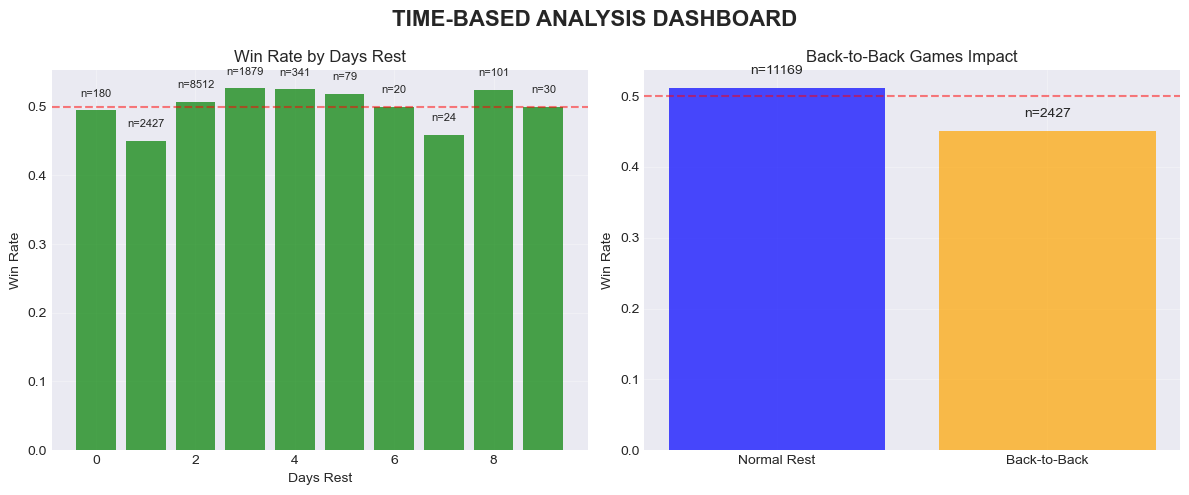

In [26]:
#  TIME-BASED ANALYSIS

print("\n" + "="*80)
print("PART 3: TIME-BASED ANALYSIS")
print("="*80)

# Check what time-based columns are actually available
print("\n📋 Available time-based columns:")
time_columns = ['game_date', 'minutes_played', 'days_rest', 'is_back_to_back', 'game_number']
available_time_cols = [col for col in time_columns if col in in_game_df.columns]
for col in available_time_cols:
    print(f"  ✓ {col}")

# Convert game_date if available
if 'game_date' in in_game_df.columns:
    in_game_df['game_date'] = pd.to_datetime(in_game_df['game_date'])
    in_game_df['year'] = in_game_df['game_date'].dt.year
    in_game_df['month'] = in_game_df['game_date'].dt.month
    in_game_df['day_of_week'] = in_game_df['game_date'].dt.dayofweek
    print("  ✓ Created month, day_of_week from game_date")

# Time-based visualizations - dynamically create subplots based on available data
available_plots = []

# Check each potential plot type
if 'month' in in_game_df.columns:
    available_plots.append('monthly')
if 'day_of_week' in in_game_df.columns:
    available_plots.append('dow')
if 'minutes_played' in in_game_df.columns:
    available_plots.append('minutes')
if 'days_rest' in in_game_df.columns:
    available_plots.append('rest')
if 'is_back_to_back' in in_game_df.columns:
    available_plots.append('b2b')
if 'game_number' in in_game_df.columns:
    available_plots.append('season')

print(f"\n📊 Available plots: {available_plots}")

# Calculate grid size
n_plots = len(available_plots)
if n_plots > 0:
    n_cols = min(3, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    fig.suptitle('TIME-BASED ANALYSIS DASHBOARD', fontsize=16, fontweight='bold')
    
    # Flatten axes for easy indexing
    if n_rows > 1:
        axes = axes.flatten()
    elif n_plots == 1:
        axes = [axes]
    
    plot_idx = 0
    
    
    
    # 1. Days rest impact
    if 'days_rest' in in_game_df.columns and 'rest' in available_plots:
        ax = axes[plot_idx]
        rest_impact = in_game_df.groupby('days_rest')['win'].agg(['mean', 'count'])
        rest_impact = rest_impact[rest_impact['count'] > 5]  # Filter low sample sizes
        
        ax.bar(rest_impact.index, rest_impact['mean'], color='green', alpha=0.7)
        ax.set_xlabel('Days Rest')
        ax.set_ylabel('Win Rate')
        ax.set_title('Win Rate by Days Rest')
        ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        # Add count labels
        for idx, value in rest_impact.iterrows():
            ax.text(idx, value['mean'] + 0.02, f'n={int(value["count"])}', ha='center', fontsize=8)
        plot_idx += 1
    
    # 2. Back-to-back games impact
    if 'is_back_to_back' in in_game_df.columns and 'b2b' in available_plots:
        ax = axes[plot_idx]
        b2b_stats = in_game_df.groupby('is_back_to_back')['win'].mean()
        b2b_counts = in_game_df.groupby('is_back_to_back')['win'].count()
        
        labels = ['Normal Rest', 'Back-to-Back'] if len(b2b_stats) > 1 else ['All Games']
        values = b2b_stats.values
        
        ax.bar(labels[:len(values)], values, color=['blue', 'orange'][:len(values)], alpha=0.7)
        ax.set_ylabel('Win Rate')
        ax.set_title('Back-to-Back Games Impact')
        ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        
        # Add count labels
        for i, (idx, count) in enumerate(b2b_counts.items()):
            if i < len(labels):
                ax.text(i, b2b_stats.iloc[i] + 0.02, f'n={count}', ha='center')
        plot_idx += 1
    
    # Hide any unused subplots
    for idx in range(plot_idx, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

else:
    print("\n❌ No time-based columns available for visualization")


In [27]:
# ----------------------------------------------------------------------
# Plot 1: Win Rate by Days Rest
# ----------------------------------------------------------------------
if 'days_rest' in in_game_df.columns:
    fig1, ax1 = plt.subplots(figsize=(8, 5))
    fig1.patch.set_alpha(0)       # transparent figure background
    ax1.patch.set_alpha(0)        # transparent axes background

    # Prepare data
    rest_impact = in_game_df.groupby('days_rest')['win'].agg(['mean', 'count'])
    rest_impact = rest_impact[rest_impact['count'] > 5]   # filter low sample sizes

    # Bar chart
    ax1.bar(rest_impact.index, rest_impact['mean'], color='green', alpha=0.7)
    ax1.set_xlabel('Days Rest')
    ax1.set_ylabel('Win Rate')
    ax1.set_title('Win Rate by Days Rest')
    ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    ax1.grid(True, alpha=0.3)

    # Add sample size labels
    for idx, value in rest_impact.iterrows():
        ax1.text(idx, value['mean'] + 0.02, f'n={int(value["count"])}', 
                 ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('winrate_by_daysrest.png', transparent=True)
    plt.close(fig1)
    print("✓ Saved: winrate_by_daysrest.png")
else:
    print("❌ 'days_rest' column not found – skipping plot 1")

# ----------------------------------------------------------------------
# Plot 2: Back-to-Back Games Impact
# ----------------------------------------------------------------------
if 'is_back_to_back' in in_game_df.columns:
    fig2, ax2 = plt.subplots(figsize=(6, 5))
    fig2.patch.set_alpha(0)
    ax2.patch.set_alpha(0)

    # Prepare data
    b2b_stats = in_game_df.groupby('is_back_to_back')['win'].mean()
    b2b_counts = in_game_df.groupby('is_back_to_back')['win'].count()
    labels = ['Normal Rest', 'Back-to-Back'] if len(b2b_stats) > 1 else ['All Games']
    values = b2b_stats.values

    # Bar chart
    ax2.bar(labels[:len(values)], values, color=['blue', 'orange'][:len(values)], alpha=0.7)
    ax2.set_ylabel('Win Rate')
    ax2.set_title('Back-to-Back Games Impact')
    ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    ax2.grid(True, alpha=0.3)

    # Add sample size labels
    for i, (idx, count) in enumerate(b2b_counts.items()):
        if i < len(labels):
            ax2.text(i, b2b_stats.iloc[i] + 0.02, f'n={count}', ha='center')

    plt.tight_layout()
    plt.savefig('backtoback_impact.png', transparent=True)
    plt.close(fig2)
    print("✓ Saved: backtoback_impact.png")
else:
    print("❌ 'is_back_to_back' column not found – skipping plot 2")

✓ Saved: winrate_by_daysrest.png
✓ Saved: backtoback_impact.png
